# TFT (Temporal Fusion Transformer) on the Stallion demand dataset

This notebook uses the `tft` model added to **TFTS** (`TFTransformer`) on the classic
[Stallion](https://pytorch-forecasting.readthedocs.io/en/stable/tutorials/stallion.html)
multi-series demand dataset. It reuses the **TFTS data pipeline**
(`tfts.data.StallionPreprocessor`) which reproduces the official PyTorch Forecasting
feature set feature-for-feature — 24 months encoder -> 6 months decoder, per-series
(agency, sku) group normalization with a softplus transform.

Steps: load the raw Stallion rows -> build fixed 24-to-6 windows -> train a TFT with a
multi-quantile loss -> inspect its median (p50) quantile forecast in original volume units.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from tfts.data.examples.stallion import StallionPreprocessor
from tfts.losses.loss import MultiQuantileLoss
from tfts.models.tft import TFTransformer, TFTransformerConfig

/Users/longxingtan/Repository/Time-series-prediction/.venv/lib/python3.12/site-packages/tensorflow/python/keras/engine/training_arrays_v1.py:37: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 2.5.2)
  from scipy.sparse import issparse  # pylint: disable=g-import-not-at-top


In [2]:
# --- Load the raw Stallion data ------------------------------------------------


def load_stallion_raw() -> pd.DataFrame:
    """Download pytorch-forecasting's bundled Stallion parquet directly via HTTP.

    This avoids pulling torch into the TFTS environment: the file is plain pandas
    (read_parquet) fetched from the upstream ``examples/data/`` folder
    """
    import tempfile
    from urllib.request import urlretrieve

    url = "https://github.com/sktime/pytorch-forecasting/raw/main/examples/data/stallion.parquet"
    cache = Path(tempfile.gettempdir()) / "stallion.parquet"
    if not cache.exists():
        urlretrieve(url, cache)
    return pd.read_parquet(cache)


data = load_stallion_raw()
print(data.shape)
data.head()

(21000, 26)


,agency,sku,volume,date,industry_volume,soda_volume,avg_max_temp,price_regular,price_actual,discount,...,labor_day,independence_day,revolution_day_memorial,regional_games,fifa_u_17_world_cup,football_gold_cup,beer_capital,music_fest,discount_in_percent,timeseries
0,Agency_22,SKU_01,52.2720,2013-01-01,492612703,718394219,25.845238,1168.903668,1069.166193,99.737475,...,0,0,0,0,0,0,0,0,8.532566,0
238,Agency_37,SKU_04,0.0000,2013-01-01,492612703,718394219,26.505000,1852.273642,1611.466298,240.807344,...,0,0,0,0,0,0,0,0,13.000635,5
237,Agency_59,SKU_03,812.9214,2013-01-01,492612703,718394219,22.219737,1270.795012,1197.184260,73.610752,...,0,0,0,0,0,0,0,0,5.792496,9
236,Agency_11,SKU_01,316.4400,2013-01-01,492612703,718394219,25.360000,1176.155397,1082.757488,93.397909,...,0,0,0,0,0,0,0,0,7.940950,14
235,Agency_05,SKU_05,420.9093,2013-01-01,492612703,718394219,24.079012,1327.003396,1207.822992,119.180404,...,0,0,0,0,0,0,0,0,8.981168,22


## 1. Preprocessing

`StallionPreprocessor.fit()` engineers the tutorial features (`time_idx`, `month`,
`log_volume`, `avg_volume_by_sku/agency`, the collapsed `special_days` category) and fits
the encoders + the per-(agency, sku) softplus target normalizer. `transform(split=...)`
then slices fixed 24-to-6 windows for either training (all legal starts) or validation
(the last six months of each series).

In [3]:
pre = StallionPreprocessor().fit(data)
train = pre.transform(data, split="train")
validation = pre.transform(data, split="validation")

print("training_cutoff:", pre.metadata()["training_cutoff"])
print("train windows:", len(train), " | validation windows:", len(validation))
print("target (normalized) shape:", train.target.shape)
print("validation target (original units) shape:", validation.target_original.shape)

training_cutoff: 53
train windows: 8750  | validation windows: 350
target (normalized) shape: (8750, 6, 1)
validation target (original units) shape: (350, 6, 1)


In [4]:
# --- Model configuration derived from the pipeline -----------------------------
QUANTILES = [0.02, 0.1, 0.25, 0.5, 0.75, 0.9, 0.98]
INPUT_KEYS = [
    "static_categorical",
    "static_real",
    "encoder_categorical",
    "encoder_real",
    "decoder_categorical",
    "decoder_real",
    "target_scale",
]

card = pre.categorical_cardinalities
config = TFTransformerConfig(
    static_real_dim=train.inputs["static_real"].shape[-1],
    encoder_real_dim=train.inputs["encoder_real"].shape[-1],
    decoder_real_dim=train.inputs["decoder_real"].shape[-1],
    static_categorical_cardinalities=card["static"],
    temporal_categorical_cardinalities=card["temporal"],
    hidden_size=32,
    num_layers=1,
    num_attention_heads=4,
    output_size=len(QUANTILES),
    output_transform="group_softplus",  # final layer maps back to original volume units
    quantiles=QUANTILES,
    attention_probs_dropout_prob=0.1,
    hidden_dropout_prob=0.1,
)
model = TFTransformer(predict_sequence_length=6, config=config)

train_inputs = {key: train.inputs[key] for key in INPUT_KEYS}
val_inputs = {key: validation.inputs[key] for key in INPUT_KEYS}
model(train_inputs)  # build the graph
print("trainable parameters:", model.count_params())

trainable parameters: 372734


In [5]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01, clipnorm=0.1),
    loss=MultiQuantileLoss(QUANTILES),
)
# Because output_transform='group_softplus' the network already emits predictions in
# original volume units, so we pass the raw labels directly.
history = model.fit(
    train_inputs,
    train.target_original,
    validation_data=(val_inputs, validation.target_original),
    batch_size=128,
    epochs=10,
    shuffle=True,
    verbose=1,
)

Epoch 1/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 67s 146ms/step - loss: 473.4465 - val_loss: 643.6190
Epoch 2/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 122ms/step - loss: 394.1599 - val_loss: 619.9334
Epoch 3/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 11s 163ms/step - loss: 368.5003 - val_loss: 584.2807
Epoch 4/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 11s 164ms/step - loss: 354.7500 - val_loss: 614.4946
Epoch 5/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 11s 163ms/step - loss: 338.5126 - val_loss: 588.3350
Epoch 6/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 11s 163ms/step - loss: 329.7366 - val_loss: 606.1889
Epoch 7/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 11s 163ms/step - loss: 312.6166 - val_loss: 602.9194
Epoch 8/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 11s 163ms/step - loss: 304.8546 - val_loss: 607.0828
Epoch 9/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 11s 164ms/step - loss: 293.1397 - val_loss: 586.8893
Epoch 10/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 11s 163ms/step - loss: 288.9166 - val_loss: 608.0627


In [6]:
# --- Forecasts (median / p50 quantile, already in original units) ----------------
quantile_preds = model.predict(val_inputs, batch_size=128, verbose=0)  # (n_series, 6, 7)
median_idx = QUANTILES.index(0.5)
pred = quantile_preds[..., median_idx : median_idx + 1][..., 0]  # (n_series, 6)
actual = validation.target_original[..., 0]  # (n_series, 6)

errors = pred - actual
print(f"MAE : {np.mean(np.abs(errors)):.2f}")
print(f"MSE : {np.mean(np.square(errors)):.2f}")

MAE : 273.64
MSE : 474549.47


## 2. Visualize validation forecasts

Each validation window holds the last 6 months (time_idx 54 -> 59) forecast against
the held-out actuals. We show the first few series with the 10-90th percentile band.

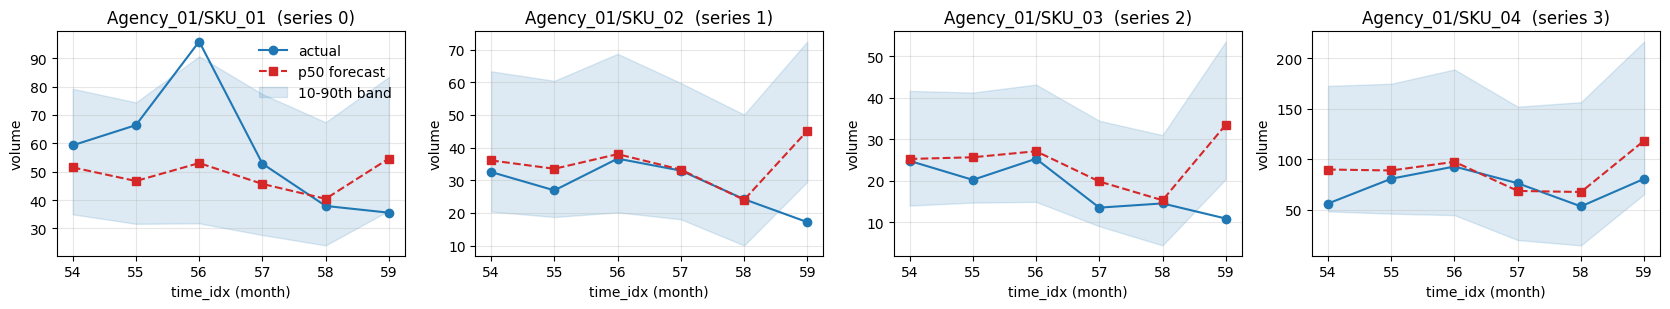

In [7]:
grid = tf.range(int(validation.decoder_time_idx.min()), int(validation.decoder_time_idx.max()) + 1)
n_show = min(4, len(validation))

fig, axes = plt.subplots(1, n_show, figsize=(4.2 * n_show, 3.2), squeeze=False)
for axis, i in zip(axes[0], range(n_show)):
    axis.plot(grid, actual[i], "o-", color="#1f77b4", label="actual")
    axis.plot(grid, pred[i], "s--", color="#d62728", label="p50 forecast")
    low, high = QUANTILES[1], QUANTILES[-2]  # 10th / 90th percentile band
    axis.fill_between(
        grid,
        quantile_preds[i, :, QUANTILES.index(low)],
        quantile_preds[i, :, QUANTILES.index(high)],
        color="#1f77b4",
        alpha=0.15,
        label="10-90th band",
    )
    key = "/".join(validation.group_keys[i])
    axis.set_title(f"{key}  (series {i})")
    axis.set_xlabel("time_idx (month)")
    axis.set_ylabel("volume")
    axis.grid(alpha=0.3)
axes[0, 0].legend(frameon=False)
fig.tight_layout()
plt.show()

## 3. Save, reload, and run inference

In [8]:
# TFTransformer is a native Keras model, so restore its config and weights.
model.config.save_pretrained("./tft_model")
model.save_weights("./tft_model/tf_model.weights.h5")

restored_config = TFTransformerConfig.from_pretrained("./tft_model")
restored_model = TFTransformer(predict_sequence_length=6, config=restored_config)
restored_model(val_inputs)  # create variables before loading weights
restored_model.load_weights("./tft_model/tf_model.weights.h5")
restored_quantiles = restored_model.predict(val_inputs, batch_size=128, verbose=0)
print("Restored prediction shape:", restored_quantiles.shape)

Restored prediction shape: (350, 6, 7)
